# 06 — Évaluation : comparaison des trois approches (FD001)

**Objectif** : comparer Random Forest, XGBoost et LSTM sur les mêmes métriques (RMSE, MAE), puis sur un score spécifique au domaine (score NASA) qui tient compte de la conséquence opérationnelle d'une erreur, pas seulement de sa taille.

In [1]:
# --- Imports et configuration ---
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.append(str(PROJECT_ROOT))

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

SUBSET = "FD001"

RESULTS_DIR = PROJECT_ROOT / "reports" / "results"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "evaluation"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Chargement des prédictions

Chaque modèle a sauvegardé ses prédictions sur le même jeu de test (100 moteurs, une prédiction par moteur).

In [2]:
MODELES = {
    "Random Forest": "random_forest",
    "XGBoost": "xgboost",
    "LSTM": "lstm",
}

predictions = {
    nom: pd.read_csv(RESULTS_DIR / f"predictions_{fichier}_{SUBSET}.csv")
    for nom, fichier in MODELES.items()
}

for nom, df in predictions.items():
    print(f"{nom} : {df.shape[0]} predictions")

Random Forest : 100 predictions
XGBoost : 100 predictions
LSTM : 100 predictions


## 2. RMSE et MAE

In [3]:
resultats = []
for nom, df in predictions.items():
    rmse = root_mean_squared_error(df["RUL_reelle"], df["RUL_predite"])
    mae = mean_absolute_error(df["RUL_reelle"], df["RUL_predite"])
    resultats.append({"modele": nom, "RMSE": rmse, "MAE": mae})

tableau_resultats = pd.DataFrame(resultats).set_index("modele")
print(tableau_resultats)

                    RMSE        MAE
modele                             
Random Forest  18.916369  14.122350
XGBoost        19.890704  14.236301
LSTM           13.189813   9.505284


**Interprétation** : le LSTM devance nettement les deux autres sur RMSE et MAE (environ 13,2 et 9,5 cycles, contre 19-20 et 14 pour Random Forest et XGBoost). Random Forest et XGBoost restent très proches l'un de l'autre.

## 3. Score NASA

RMSE et MAE traitent une sur-estimation et une sous-estimation de la même ampleur comme des erreurs équivalentes. Or ce n'est pas vrai en pratique :

- **Sur-estimer** la RUL (prédire plus de temps qu'il n'en reste réellement) donne une **prédiction tardive** — on continuerait à faire voler un moteur qui est en réalité proche de la panne. C'est le cas dangereux.
- **Sous-estimer** la RUL (prédire moins de temps qu'il n'en reste) donne une **prédiction précoce** — on retirerait le moteur du service un peu trop tôt. C'est sans risque, juste un peu de temps de vol perdu.

Le score NASA reflète cette asymétrie : il pénalise beaucoup plus fortement une sur-estimation qu'une sous-estimation de même ampleur. Concrètement, pour un écart `d = RUL prédite − RUL réelle` :

- si `d < 0` (sous-estimation, prédiction précoce) → pénalité `exp(-d/13) - 1`
- si `d >= 0` (sur-estimation, prédiction tardive) → pénalité `exp(d/10) - 1`

Le dénominateur plus petit (10 contre 13) fait grimper la pénalité plus vite du côté dangereux.

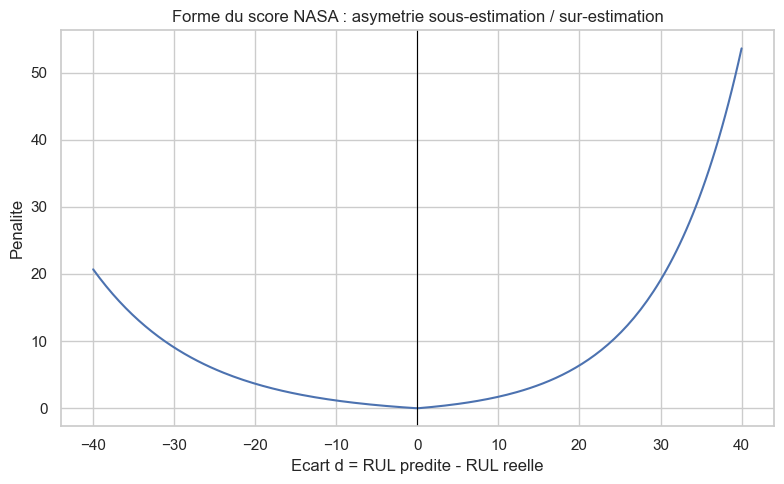

In [4]:
def score_nasa(y_reel, y_predit):
    d = y_predit - y_reel
    penalites = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return penalites


fig, ax = plt.subplots(figsize=(8, 5))
d = np.linspace(-40, 40, 200)
penalites = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
ax.plot(d, penalites)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Ecart d = RUL predite - RUL reelle")
ax.set_ylabel("Penalite")
ax.set_title("Forme du score NASA : asymetrie sous-estimation / sur-estimation")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "score_nasa_forme.png")
plt.show()

**Interprétation** : on voit bien l'asymétrie recherchée sur la courbe — à écart égal (40 cycles par exemple), une sur-estimation coûte environ 54 de pénalité contre 21 pour une sous-estimation, soit plus de 2 fois plus punitif du côté dangereux.

## 4. Comparaison des trois modèles

In [5]:
for nom, df in predictions.items():
    penalites = score_nasa(df["RUL_reelle"], df["RUL_predite"])
    tableau_resultats.loc[nom, "Score NASA (somme)"] = penalites.sum()
    tableau_resultats.loc[nom, "Score NASA (moyenne)"] = penalites.mean()

print(tableau_resultats.round(2))

                RMSE    MAE  Score NASA (somme)  Score NASA (moyenne)
modele                                                               
Random Forest  18.92  14.12             1446.44                 14.46
XGBoost        19.89  14.24             1611.18                 16.11
LSTM           13.19   9.51              289.42                  2.89


**Interprétation** : l'écart entre les modèles s'accentue fortement avec le score NASA : le LSTM (score moyen 2,89) devance très largement Random Forest (14,46) et XGBoost (16,11) — environ 5 fois moins de pénalité, alors que l'écart n'était que de 30-50 % sur le RMSE. Ça indique que les erreurs de Random Forest et XGBoost contiennent plus de cas de sur-estimation dangereuse, le type d'erreur le plus pénalisé.

## 5. Prédictions vs réalité

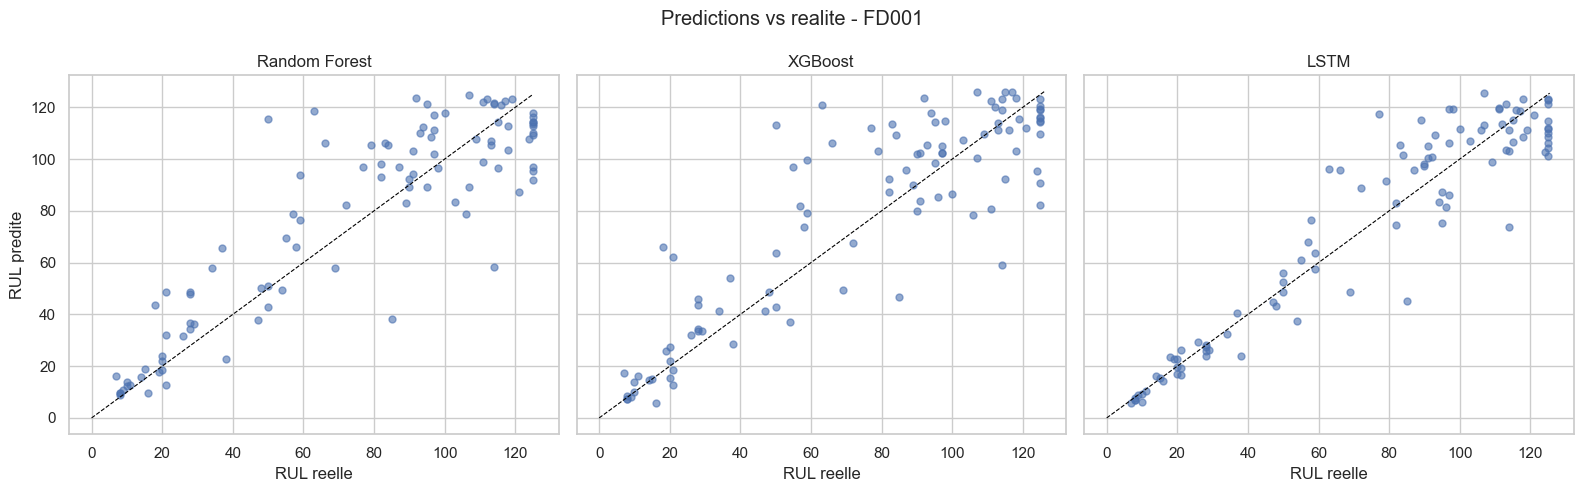

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

for ax, (nom, df) in zip(axes, predictions.items()):
    ax.scatter(df["RUL_reelle"], df["RUL_predite"], alpha=0.6, s=25)
    limite = max(df["RUL_reelle"].max(), df["RUL_predite"].max())
    ax.plot([0, limite], [0, limite], color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("RUL reelle")
    ax.set_title(nom)

axes[0].set_ylabel("RUL predite")
fig.suptitle(f"Predictions vs realite - {SUBSET}")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "predictions_vs_realite.png")
plt.show()

**Interprétation** : sur le nuage de points, le LSTM est visiblement plus resserré autour de la diagonale, en particulier pour les RUL basses — la zone la plus critique, proche de la panne — cohérent avec son meilleur score NASA. Random Forest et XGBoost ont plusieurs points nettement au-dessus de la diagonale à RUL moyenne, c'est-à-dire des cas de sur-estimation, justement ceux que le score NASA pénalise le plus fortement.

## Synthèse

Sur les trois métriques (RMSE, MAE, score NASA), le LSTM devance Random Forest et 
XGBoost, avec un écart qui se creuse nettement sur le score NASA — le plus 
représentatif du risque opérationnel réel, puisqu'il pénalise davantage les erreurs 
dangereuses (sur-estimation) que les erreurs prudentes (sous-estimation).

Random Forest et XGBoost restent proches l'un de l'autre sur les trois métriques, 
sans qu'aucun des deux ne se distingue nettement.

| Modèle | RMSE | MAE | Score NASA (moyenne) |
|---|---|---|---|
| Random Forest | 18,92 | 14,12 | 14,46 |
| XGBoost | 19,89 | 14,24 | 16,11 |
| LSTM | 13,19 | 9,51 | 2,89 |
